# AtoMLtype Quickstart Guide: From SDF file to Inference

## Import Libraries & Set Logging Config




In this section, we import the required libraries and configure logging to help us track the dataset loading process. Logging is especially helpful for debugging and monitoring when working with large numbers of molecules.

> **Note:** After running this cell, log messages from dataset loading and processing will be printed in your terminal and saved in `dataset_loader.log` for later review.


In [1]:
from torch.utils.data import random_split
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)


from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelEncoder import ModelEncoder
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN
from atoMLtype.models.ModelTrainer import GNNTrainer
from atoMLtype.models.ModelEngine import ModelEngine


[2025-04-29 17:38:03,134] INFO - Enabling RDKit 2024.03.5 jupyter extensions
[2025-04-29 17:38:03,704] INFO - NumExpr defaulting to 10 threads.


## **Part 1. Load the Molecules into GNNDataset**

### 1A. `ModelEncoder`
The `ModelEncoder` class manages atom-type label processing for training and inference. It wraps around scikit-learn’s `LabelEncoder` but **adds extra functionality** tailored for atom typing:

- **Label collapsing:** Merges equivalent atom types (e.g., `'cp'`, `'cq'` → `'c_pq'`) for symmetric treatment of conjugated systems.
- **Inverse transformation:** Decodes numeric predictions back into human-readable labels.

When `collapse=True` (default for this project), atom types from the GAFF2 force field that represent alternating conjugation are merged to reduce label complexity during training.  For other labels, alternative mappings can be passed to the `ModelEncoder`

The encoder must be **fit** on the dataset’s atom-type labels before use and ensures that the model expects consistent label spaces across training and inference.

> **Note:**  
> The framework currently assumes the same atom-type label space (i.e., the same set of atom types) between training and inference datasets.  
> If inference molecules contain unseen atom types, the model will raise an error.


In [2]:
dataset_encoder = ModelEncoder(collapse=True)


### 1B. `GNNdataset`
The `GNNdataset` class builds complete graph datasets for training and inference only.

It **wraps an `SDFdataset` instance**, which loads:
- RDKit molecule objects (`Chem.Mol`)
- Atom-type labels (optional, from a `.json` file)

It then **converts each molecule** into a **PyTorch Geometric** `Data` graph object:
- **Nodes:** Atoms, with featurized properties
- **Edges:** Bonds, optionally directed
- **Labels (`y`):** Atom-type classes encoded by `ModelEncoder` (if available)

Key parameters:

| Parameter        | Description |
| :---------------- | :---------- |
| `labeled`          | If `True`, only molecules with complete atom-type labels are used (for training). If `False`, allows molecules without labels (for inference). |
| `directed_graph`   | If `True`, graph edges represent bonds as directed. Otherwise, edges are undirected. |

Throughout this project, the **default settings** are:
- `labeled = True`
- `directed_graph = True`

> **Note:**
When `labeled = true`, any Chem.Mol without a complete set of labels in the json file will be skipped and noted in the json file "nonlabeled_molecules_{sdf_name}.json"

In [3]:
# Load the ZINC files
zinc_sdf_path = "./data/parm_at_Frosst/zinc.sdf"
zinc_json_labels = "./data/antechamber/atomLabels_gaff2.json"

zinc_dataset = GNNdataset(sdf_path=zinc_sdf_path, 
                          label_path=zinc_json_labels, 
                          directed_graph=True,
                          labeled=True,
                          encoder=dataset_encoder)

[2025-04-29 17:38:04,254] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-29 17:38:04,333] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-29 17:38:04,366] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-29 17:38:04,447] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-29 17:38:04,507] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-29 17:38:04,566] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-29 17:38:04,616] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-29 17:38:04,634] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025-04-29 17:38:04,709] WARNING - Atom count mismatch for ZINC17108217: 25 ato

### 1C. Train/Test Split and Label Distribution

Now that we’ve loaded and processed our molecular dataset into graph representations, we’ll split the data into **training** and **test** sets using a standard 90/10 random split.

This ensures that our model is trained and evaluated on **distinct, non-overlapping molecules**.

Before training, we’ll also plot the **distribution of atom-type labels** (using a method from "analysis/") across the **entire dataset** to assess class balance. This is important for detecting label imbalance, which can impact model performance.

We will access the `encoded_labels` attribute of the `GNNdataset` instance, which contains all atom-type labels used in the `graph.y` data, and convert them back to their original string form using the `ModelEncoder`'s `inverse_transform()` method.

FULL DATASET (encoded):


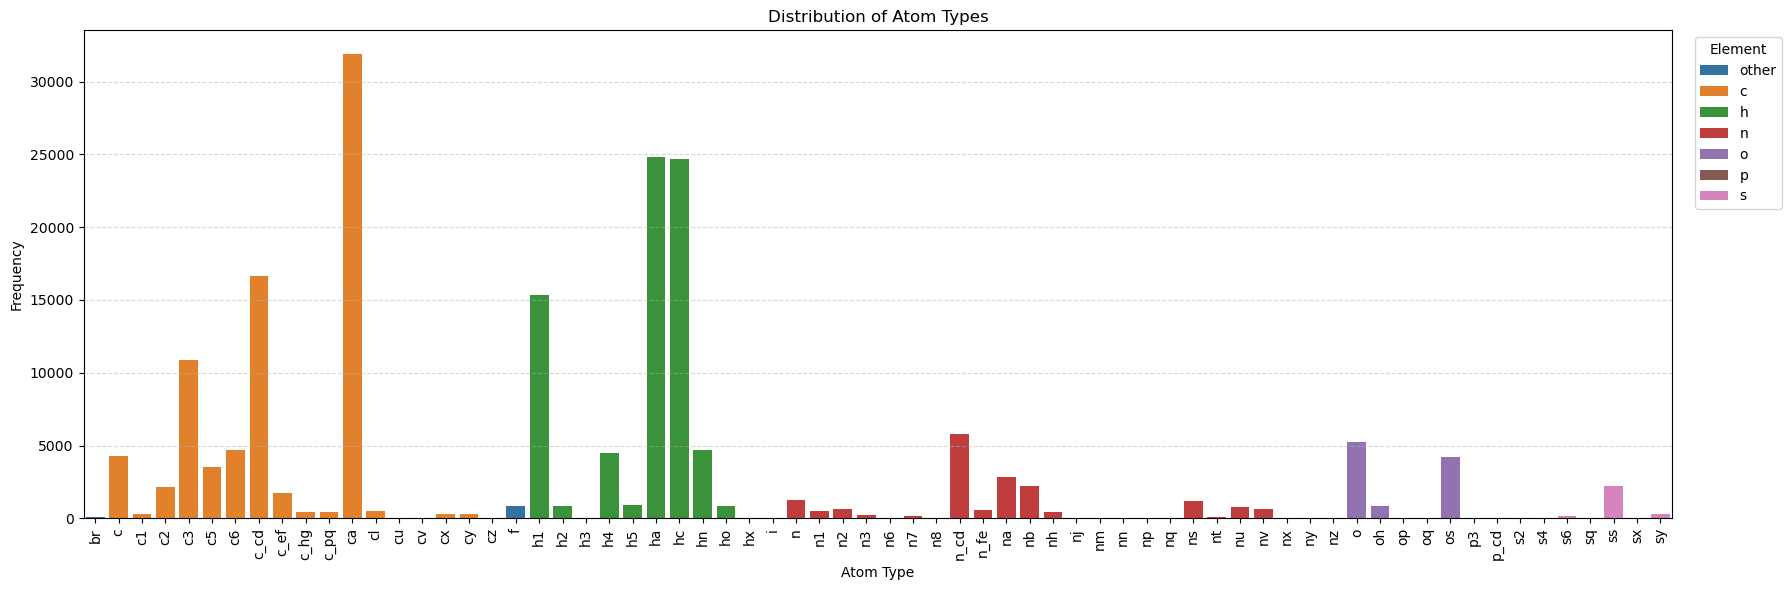

In [4]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(zinc_dataset))
test_size = len(zinc_dataset) - train_size
train_dataset, test_dataset = random_split(zinc_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(dataset_encoder.inverse_transform(zinc_dataset.encoded_labels)))

## **Part 2. Model Training**


### 2A. Instantiate the `AtomBondMPNN` Model

In this section, we define and instantiate our **Message-Passing Neural Network (MPNN)** model tailored for atom-type classification.

The model architecture is based on a **Directed Message Passing Neural Network (D-MPNN)** variant that passes messages between atoms using both atom and bond features. It consists of:

- A **linear projection** from input atom features to a hidden embedding space. (`atom_encoder`)
- A stack of **edge-conditioned message-passing layers** (`AtomBondMPNNLayer`) that aggregate information from bonded neighbors.
- An optional **attention mechanism** that adaptively weights messages between atoms. (`att_mlp`)
- A final **MLP classifier** head that outputs logits for atom-type prediction. (`classifer`)

We use the dimensionality of the atom and bond features from our dataset to initialize the input layers correctly. The model is also passed the `ModelEncoder` used earlier to manage label encoding.

> **Key Parameters:**
> - `atom_input_dim`: Number of features per atom (from `Data.x`)
> - `bond_input_dim`: Number of features per bond (from `Data.edge_attr`)
> - `hidden_dim`: Size of the intermediate hidden layers (512 in this case)
> - `num_layers`: Number of message-passing layers (10 layers here)
> - `use_attention`: Enables message-level attention weighting



In [5]:

atom_node_dim = train_dataset[0].x.shape[1]
bond_edge_dim = train_dataset[0].edge_attr.shape[1]

AtomMPNN_zinc = AtomBondMPNN(atom_input_dim=atom_node_dim, 
                             bond_input_dim=bond_edge_dim, 
                             hidden_dim=512,
                             encoder=dataset_encoder, 
                             num_layers=10,
                             use_attention=True)

### 2B. Model Training with `GNNTrainer`

Now that we have instantiated our `AtomBondMPNN` model, the next step is to **train** it on our molecular graphs.

We use the `GNNTrainer` class, a flexible training wrapper that supports:
- Standard training on a single train/test split
- **K-Fold cross-validation** for a more rigorous evaluation of model performance
- Training loss and validation curve visualization 
- Output of loss per epoch dictionary for further analysis

**GNNTrainer Configuration Options:**

| Parameter | Description |
|:---|:---|
| `model` | The GNN model to train (must subclass `BaseGNNModel`) |
| `dataset` | The dataset of molecular graphs (`GNNdataset`) |
| `batch_size` | Number of graphs processed together in each mini-batch |
| `learning_rate` | Learning rate for the Adam optimizer |
| `epochs` | Number of training epochs |
| `k_folds` | Number of folds for K-Fold cross-validation (if `None`, uses standard train/test split) |
| `random_seed` | Seed for reproducibility when shuffling data in K-Fold |

**Training Modes Overview:**
| Mode        | Description |
| :---------------- | :---------- |
| Standard Training | Trains once on all available training data.
| K-Fold Cross-Validation | Splits the dataset into `k` folds, trains on `k-1` folds, and validates on the remaining fold, rotating folds each time. Helps evaluate model generalization more robustly. |

In [6]:
trainer = GNNTrainer(AtomMPNN_zinc, 
                     dataset=train_dataset, 
                     batch_size=32, learning_rate=0.001,
                     epochs=5, 
                     k_folds=5, 
                     random_seed=21)

AtomBondMPNN - Number of parameters: 10985550


### 2C. **`.train()` Method Options**

| Parameter     | Description |
|---------------|-------------|
| `draw_curve`  | Whether to plot the loss curve after training (`True` by default) |
| `verbose`     | If `True`, prints training/validation loss every `report_step` epochs |
| `report_step` | Frequency (in epochs) at which loss is printed (default: 5) |
| `force`       | If `True`, forces retraining even if the model is already marked as trained |


> **Note:**
> The `.train()` method returns a dictionary containing:
> - `"train_loss"`: A list of loss values per epoch (standard training), or a list of lists (k-fold training)
> - `"val_loss"`: Only returned during k-fold training, tracking per-fold validation loss over epochs  
> This output can be used to generate custom plots or diagnose convergence.


--- Fold 1/5 ---


Epoch 1: Train Loss = 6.5569, Val Loss = 0.2110
Epoch 5: Train Loss = 0.1097, Val Loss = 0.1206
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0578, Val Loss = 0.0401
Epoch 5: Train Loss = 0.0293, Val Loss = 0.0104
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0221, Val Loss = 0.0247
Epoch 5: Train Loss = 0.0183, Val Loss = 0.0458
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0239, Val Loss = 0.0315
Epoch 5: Train Loss = 0.0158, Val Loss = 0.0178
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0173, Val Loss = 0.0108
Epoch 5: Train Loss = 0.0118, Val Loss = 0.0102


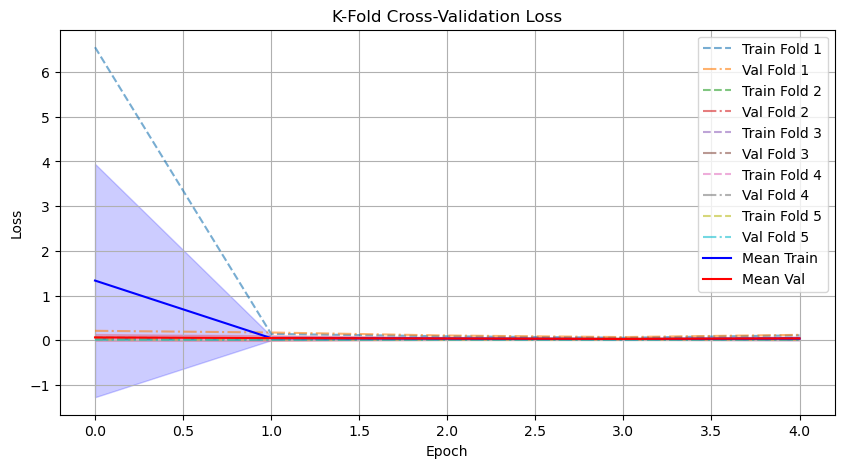

In [7]:
training_loss_ouput = trainer.train(draw_curve=True,
                                    verbose=True,
                                    report_step=5
                                    )

## **Part 3. Model Inference**

### 3A. Model Inference with `ModelEngine`

After training, we now use our model to **predict atom types on unseen molecules** from the test dataset.  
To do this, we use the `ModelEngine`, which performs batched inference and collects results in a structured, analysis-ready format.

**ModelEngine Parameters**

| Parameter     | Description |
|---------------|-------------|
| `model`       | Trained GNN model (e.g., `AtomBondMPNN`) |
| `dataset`     | Dataset of molecular graphs inference is to be performed on (test split in this case) |
| `device`      | Torch device string (`'cpu'` or `'cuda'`) |
| `batch_size`  | Number of molecules processed per inference batch |


In [8]:
modelEngine_zinc = ModelEngine(model=AtomMPNN_zinc, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

### 3B. Prediction Output and Summary with `PredictionRecord`

Once inference is complete, the `.predict()` method returns a `PredictionRecord` object, a structured container that holds atom-level prediction results for every molecule in the dataset.

Each prediction is stored as an `AtomResult`, which includes:

- `mol_name`, `atom_idx_in_mol`, `global_atom_idx`
- `true_label` and `pred_label` (decoded via `ModelEncoder`)
- `confidence` (softmax probability of the predicted class)
- `logits` (raw model outputs before softmax)
- `analysis` (optional intermediate features like embeddings)


**Key Methods and Properties of `PredictionRecord`**

| Attribute / Method         | Description |
|----------------------------|-------------|
| `.true_labels` / `.pred_labels` | Lists of all ground truth and predicted labels |
| `.matches` / `.mismatches`     | Lists of correctly and incorrectly predicted atoms |
| `.mismatched_molecules`        | Dictionary of molecule names and their incorrect predictions |
| `.to_dataframe()`              | Converts results to a `pandas.DataFrame` for export or plotting |
| `.summary()`                   | Prints a concise overview of prediction performance and stats |




In [9]:
pred_record = modelEngine_zinc.predict(analysis=False)

pred_record.summary()

Prediction Summary: 18473/18504 correct (99.83% accuracy)
True label distribution: Counter({'ca': 3258, 'ha': 2536, 'hc': 2385, 'c_cd': 1709, 'h1': 1440, 'c3': 1015, 'n_cd': 640, 'o': 516, 'c6': 486, 'hn': 470, 'h4': 452, 'c': 421, 'os': 413, 'c5': 316, 'na': 306, 'ss': 247, 'nb': 228, 'c2': 196, 'c_ef': 163, 'n': 123, 'ns': 108, 'nu': 90, 'h5': 86, 'f': 81, 'oh': 69, 'ho': 69, 'n2': 66, 'cl': 64, 'nv': 61, 'h2': 55, 'n1': 53, 'c_pq': 50, 'n_fe': 48, 'c_hg': 45, 'cx': 41, 'nh': 40, 'sy': 25, 'cy': 25, 'c1': 22, 's6': 18, 'n3': 14, 'nt': 13, 'cv': 9, 'br': 8, 'n7': 5, 'n8': 5, 'sx': 3, 'nm': 2, 'i': 1, 'op': 1, 'nq': 1, 'oq': 1, 'p_cd': 1, 'p3': 1, 's4': 1, 'nz': 1, 'nj': 1})
Pred label distribution: Counter({'ca': 3270, 'ha': 2535, 'hc': 2386, 'c_cd': 1698, 'h1': 1440, 'c3': 1015, 'n_cd': 638, 'o': 516, 'c6': 486, 'hn': 470, 'h4': 452, 'c': 422, 'os': 413, 'c5': 316, 'na': 307, 'ss': 247, 'nb': 230, 'c2': 196, 'c_ef': 167, 'n': 123, 'ns': 108, 'nu': 90, 'h5': 86, 'f': 81, 'oh': 69, 'ho

This shows:

- Overall prediction accuracy  
- Distribution of true and predicted labels  
- Confidence range (min, mean, max)  
- Summary of any captured analysis keys (if `analysis=True` was used)
